Այս բջիջում ներմուծվել են անհրաժեշտ գրադարանները տվյալների վերլուծության, տեսողականացման և DBSCAN կլաստերավորման համար։

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

Այս բջիջում բեռնվել է տվյալների հավաքածուն Google Colab միջավայր

In [3]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


Այս բջիջում ապազիպավորվել է տվյալների հավաքածուն հետագա մշակման համար։

In [4]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('earthquake_data')

Այս բջիջում ներբեռնվել է տվյալների հավաքածուն և ցուցադրվել են առաջին հինգ տողերը։

In [5]:
df = pd.read_csv('earthquake_data/database.csv')
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


Այս բջիջում հաշվվել են տվյալների հավաքածուի տողերի և սյունակների քանակները։

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 23412
Columns: 21


Այս բջիջում ցուցադրվել է տվյալների կառուցվածքը և սյունակների տիպերը։

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

Այս բջիջում ներկայացվել է թվային սյունակների վիճակագրական ամփոփումը։



In [8]:
df.describe()

,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000


Այս բջիջում հաշվվել են յուրաքանչյուր սյունակում բացակայող արժեքների քանակները։

In [9]:
df.isnull().sum()

,0
Date,0
Time,0
Latitude,0
Longitude,0
Type,0
Depth,0
Depth Error,18951
Depth Seismic Stations,16315
Magnitude,0
Magnitude Type,3


Այս բջիջում ցուցադրվել են միայն այն սյունակները, որոնք պարունակում են բացակայող արժեքներ։

In [10]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Depth Error,18951
Depth Seismic Stations,16315
Magnitude Type,3
Magnitude Error,23085
Magnitude Seismic Stations,20848
Azimuthal Gap,16113
Horizontal Distance,21808
Horizontal Error,22256
Root Mean Square,6060


Այս բջիջում հաշվվել են Type սյունակի արժեքների հաճախականությունները։

In [11]:
df["Type"].value_counts()

,count
Type,
Earthquake,23232
Nuclear Explosion,175
Explosion,4
Rock Burst,1


Այս բջիջում հաշվվել են Magnitude Type սյունակի արժեքների հաճախականությունները։

In [12]:
df["Magnitude Type"].value_counts()

,count
Magnitude Type,
MW,7722
MWC,5669
MB,3761
MWB,2458
MWW,1983
MS,1702
ML,77
MWR,26
MD,6


Այս բջիջում ստուգվել են Latitude և Longitude սյունակների բացակայող արժեքները։

In [14]:
df[['Latitude', 'Longitude']].isnull().sum()

,0
Latitude,0
Longitude,0


Այս բջիջում հաշվվել են կրկնվող տողերի քանակները։

In [15]:
df.duplicated().sum()

np.int64(0)

Այս բջիջում ցուցադրվել են Latitude և Longitude սյունակների տվյալների տիպերը։

In [16]:
df[['Latitude', 'Longitude']].dtypes

,0
Latitude,float64
Longitude,float64


Այս բջիջում ստուգվել են աշխարհագրական սահմաններից դուրս գտնվող արժեքները։

In [17]:
df[
    (df['Latitude'] < -90) |
    (df['Latitude'] > 90) |
    (df['Longitude'] < -180) |
    (df['Longitude'] > 180)
]

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status


Այս բջիջում ներկայացվել է երկրաշարժերի աշխարհագրական բաշխումը։

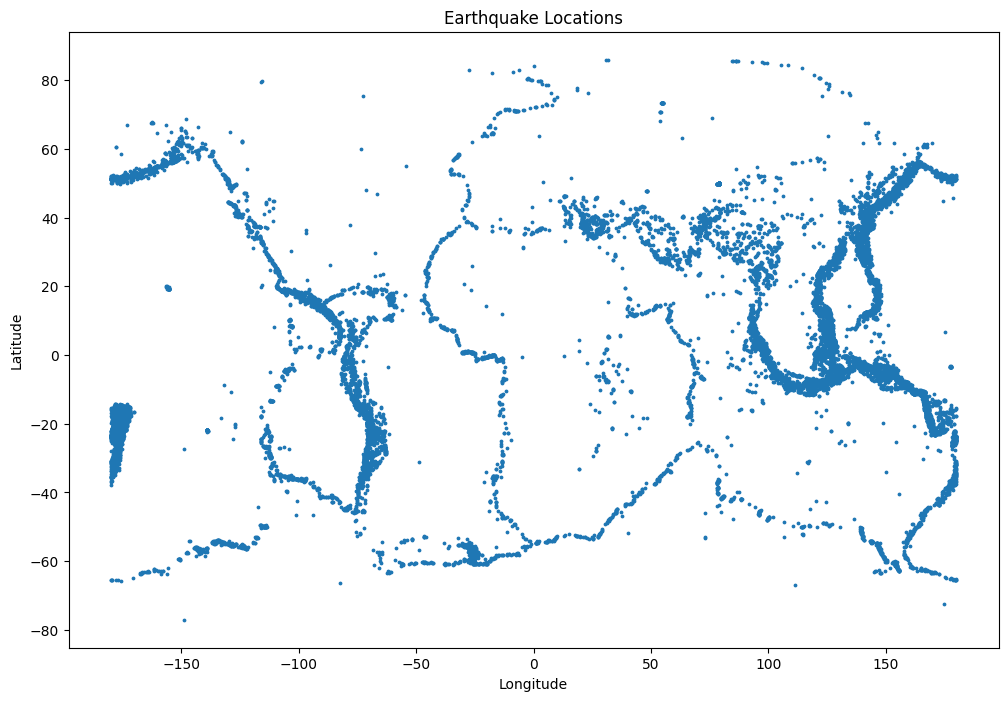

In [18]:
plt.figure(figsize=(12,8))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    s=3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquake Locations")

plt.show()

Այս բջիջում ընտրվել են Latitude և Longitude սյունակները և կատարվել է տվյալների նորմավորում։

In [22]:
X = df[['Latitude', 'Longitude']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Այս բջիջում կիրառվել է DBSCAN կլաստերավորման ալգորիթմը և ստացված պիտակները ավելացվել են տվյալների հավաքածուին։

In [23]:
dbscan = DBSCAN(
    eps=0.15,
    min_samples=20
)

labels = dbscan.fit_predict(X_scaled)

df['Cluster'] = labels

Այս բջիջում հաշվվել են հայտնաբերված կլաստերների և աղմուկային կետերի քանակները։

In [24]:
print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", list(labels).count(-1))

Number of clusters: 8
Noise points: 135


Այս բջիջում վիզուալիզացվել են DBSCAN-ի միջոցով հայտնաբերված երկրաշարժային թեժ կետերը։

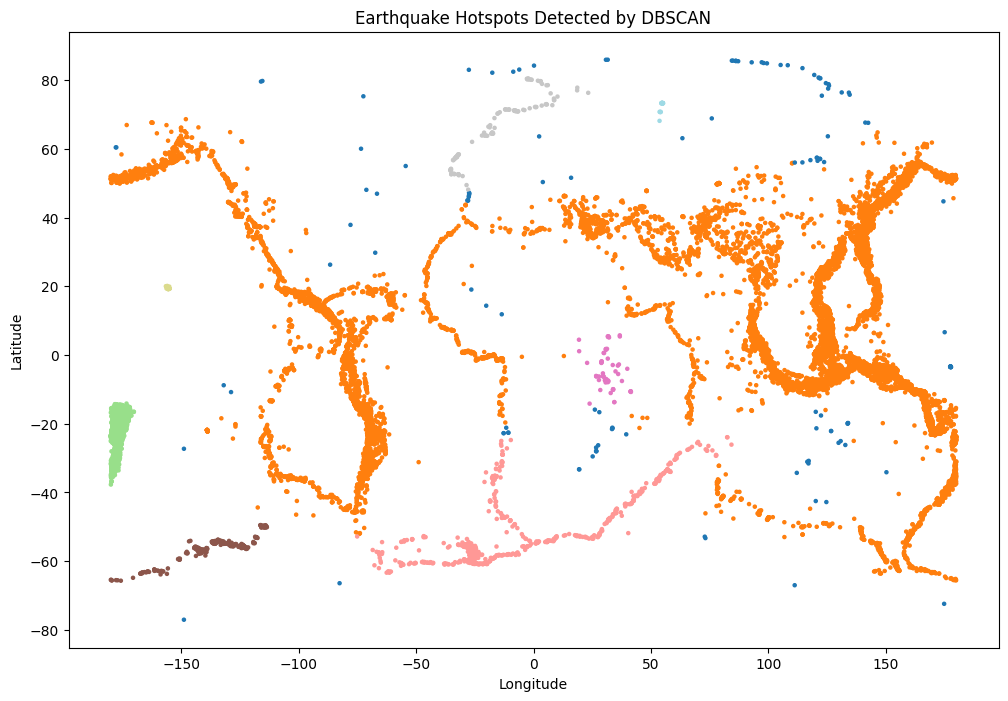

In [44]:
plt.figure(figsize=(12,8))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    c=df['Cluster'],
    cmap='tab20',
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquake Hotspots Detected by DBSCAN")

plt.show()

Այս բջիջում հաշվվել է թվային սյունակների կոռելացիայի մատրիցը։

In [26]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

Այս բջիջում կոռելացիայի մատրիցը ներկայացվել է heatmap-ի միջոցով։

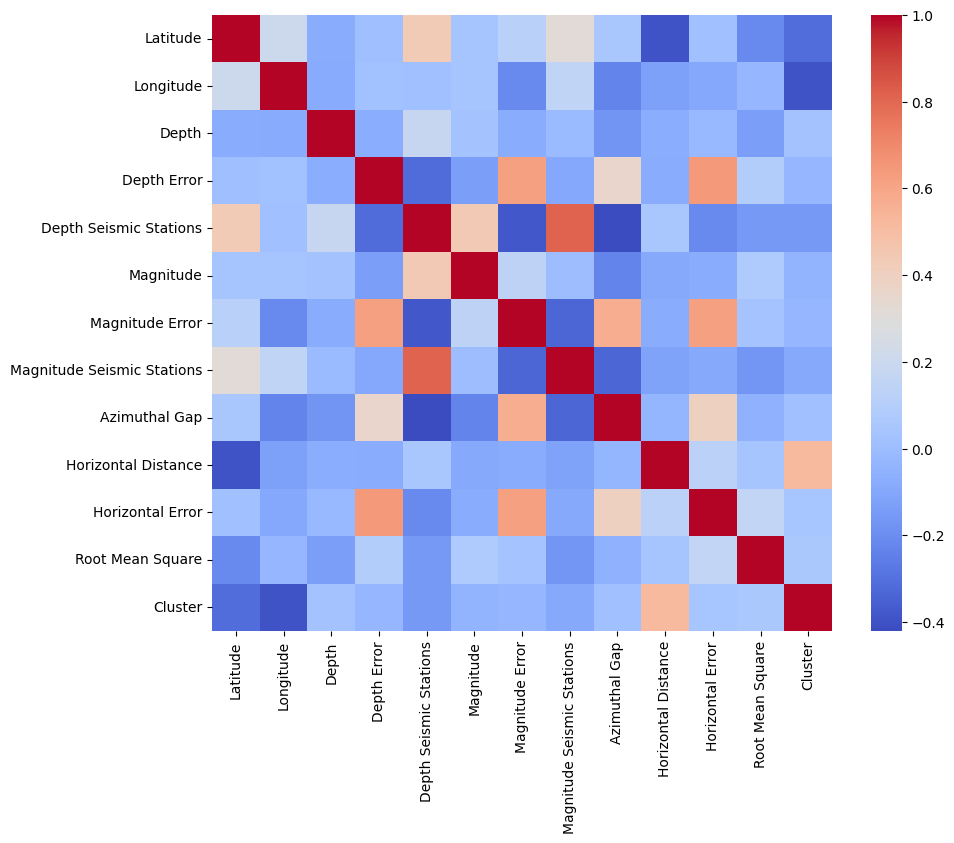

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

Այս բջիջում կառուցվել է Magnitude սյունակի boxplot-ը՝ ծայրահեղ արժեքները հայտնաբերելու համար։

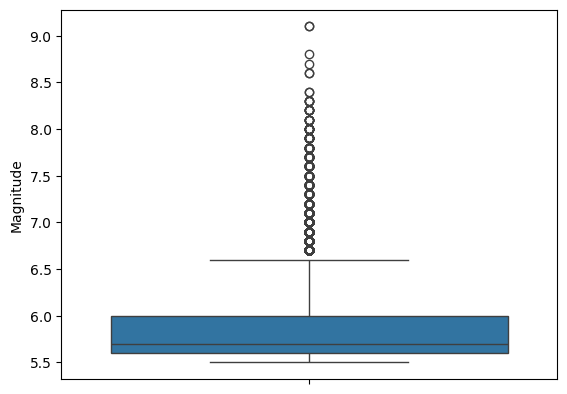

In [28]:
sns.boxplot(y=df['Magnitude'])
plt.show()

Այս բջիջում կառուցվել է Depth սյունակի boxplot-ը՝ ծայրահեղ արժեքները հայտնաբերելու համար։

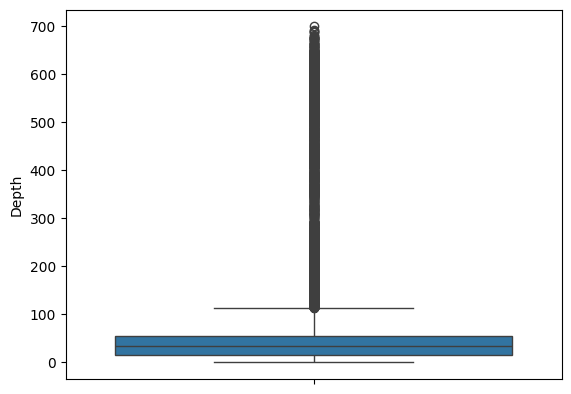

In [29]:
sns.boxplot(y=df['Depth'])
plt.show()

Այս բջիջում IQR մեթոդի միջոցով հայտնաբերվել և հաշվվել են Magnitude սյունակի ծայրահեղ արժեքները։

In [30]:
Q1 = df['Magnitude'].quantile(0.25)
Q3 = df['Magnitude'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_mag = df[
    (df['Magnitude'] < lower) |
    (df['Magnitude'] > upper)
]

print("Number of magnitude outliers:", len(outliers_mag))

Number of magnitude outliers: 1475


In [31]:
outliers_mag.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status,Cluster
5,01/10/1965,13:36:32,-13.405,166.629,Earthquake,35.0,NaN,NaN,6.7,MW,...,NaN,NaN,NaN,NaN,ISCGEM860922,ISCGEM,ISCGEM,ISCGEM,Automatic,0
11,01/24/1965,00:11:17,-2.608,125.952,Earthquake,20.0,NaN,NaN,8.2,MW,...,NaN,NaN,NaN,NaN,ISCGEM861299,ISCGEM,ISCGEM,ISCGEM,Automatic,0
16,02/04/1965,05:01:22,51.251,178.715,Earthquake,30.3,NaN,NaN,8.7,MW,...,NaN,NaN,NaN,NaN,OFFICIAL19650204050122_30,OFFICIAL,ISCGEM,OFFICIAL,Automatic,0
26,02/04/1965,08:40:44,51.443,179.605,Earthquake,30.0,NaN,NaN,7.3,MW,...,NaN,NaN,NaN,NaN,ISCGEM859264,ISCGEM,ISCGEM,ISCGEM,Automatic,0
62,02/23/1965,22:11:47,-25.633,-70.679,Earthquake,35.0,NaN,NaN,7.0,MW,...,NaN,NaN,NaN,NaN,ISCGEM860516,ISCGEM,ISCGEM,ISCGEM,Automatic,0


Այս բջիջում հաշվվել է ծայրահեղ արժեքների տոկոսային բաժինը տվյալների հավաքածուում։

In [32]:
percentage = len(outliers_mag) / len(df) * 100

print(f"Outlier percentage: {percentage:.2f}%")

Outlier percentage: 6.30%


Այս բջիջում կառուցվել է Magnitude սյունակի հիստոգրամը՝ երկրաշարժերի ուժգնության բաշխումը տեսողականորեն ուսումնասիրելու համար։


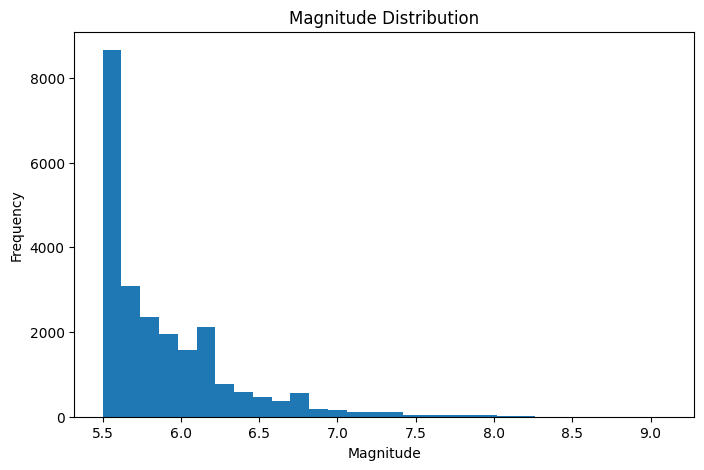

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df['Magnitude'], bins=30)

plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.title("Magnitude Distribution")

plt.show()

Այս բջիջում scatter plot-ի միջոցով ներկայացվել են Magnitude սյունակի արժեքները՝ առանձնացնելով հայտնաբերված ծայրահեղ արժեքները (outliers)։


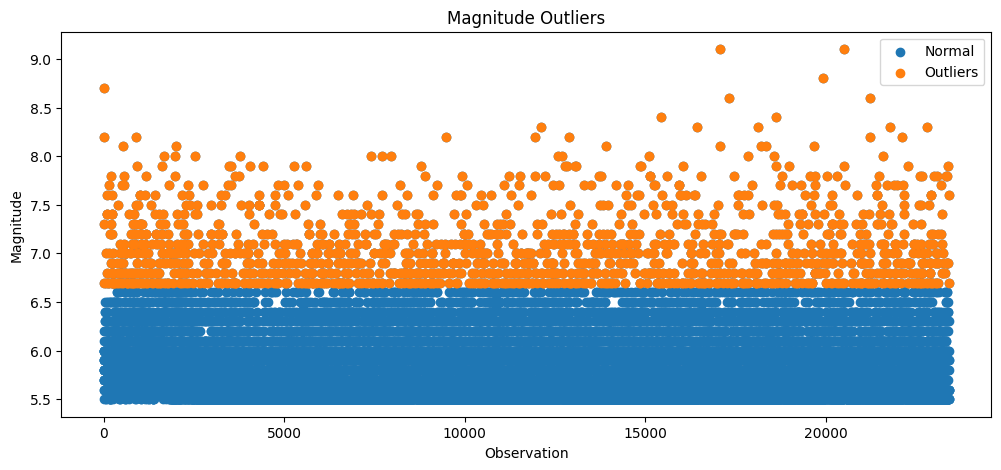

In [35]:
plt.figure(figsize=(12,5))

plt.scatter(df.index, df['Magnitude'], label='Normal')

plt.scatter(
    outliers_mag.index,
    outliers_mag['Magnitude'],
    label='Outliers'
)

plt.xlabel("Observation")
plt.ylabel("Magnitude")
plt.title("Magnitude Outliers")
plt.legend()

plt.show()

Այս բջիջում հեռացվել են Magnitude սյունակի ծայրահեղ արժեքները և կառուցվել է հիստոգրամ՝ դրանց հեռացումից հետո տվյալների բաշխումը ուսումնասիրելու համար։


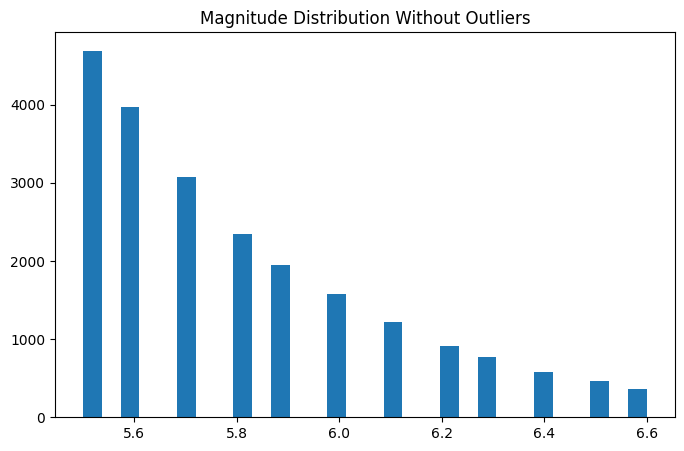

In [36]:
df_no_outliers = df[
    (df['Magnitude'] >= lower) &
    (df['Magnitude'] <= upper)
]

plt.figure(figsize=(8,5))

plt.hist(df_no_outliers['Magnitude'], bins=30)

plt.title("Magnitude Distribution Without Outliers")

plt.show()

Այս բջիջում քարտեզային scatter plot-ի միջոցով ներկայացվել են երկրաշարժերի աշխարհագրական դիրքերը՝ առանձնացնելով Magnitude սյունակի ծայրահեղ արժեքները (outliers)։


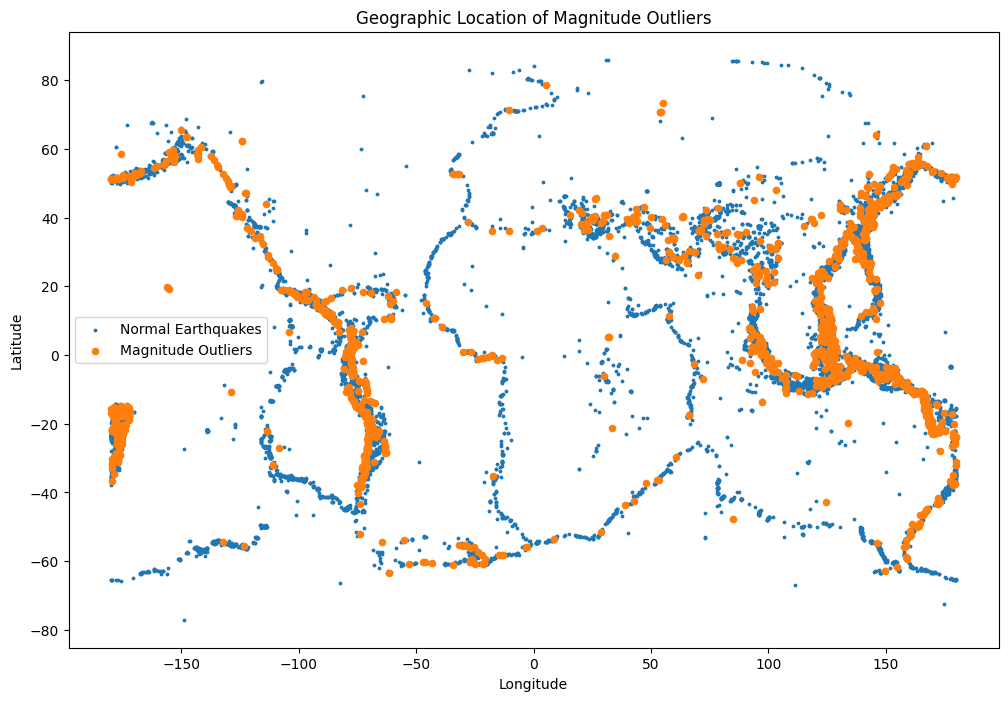

In [37]:
plt.figure(figsize=(12,8))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    s=3,
    label='Normal Earthquakes'
)

plt.scatter(
    outliers_mag['Longitude'],
    outliers_mag['Latitude'],
    s=20,
    label='Magnitude Outliers'
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Location of Magnitude Outliers")
plt.legend()

plt.show()

Այս կոդը օգտագործում է KNN (Nearest Neighbors) մեթոդը՝ երկրաշարժերի տվյալներում «hotspot»-ներ (շատ խիտ/ակտիվ տարածքներ) գտնելու համար։

Սկզբում վերցվում են միայն աշխարհագրական կոորդինատները՝ Latitude և Longitude։ Այնուհետև KNN ալգորիթմը յուրաքանչյուր կետի համար գտնում է իր 10 ամենամոտ հարևանները և հաշվում է այդ հեռավորությունների միջին արժեքը։ Սա օգտագործվում է որպես «density» (խտության չափում)․ որքան փոքր է միջին հեռավորությունը, այնքան տվյալ կետը ավելի խիտ տարածքում է գտնվում։

Հետո այդ density արժեքների հիման վրա վերցվում է ամենացածր 20%-ը (quantile 0.2), և այդ կետերը նշվում են որպես hotspot-ներ։

Վերջում ամեն ինչ պատկերվում է քարտեզի վրա․ մոխրագույն կետերը սովորական երկրաշարժերն են, իսկ կարմիր կետերը՝ KNN-ով հայտնաբերված բարձր ակտիվության (hotspot) տարածքները։


In [38]:
X = df[['Latitude', 'Longitude']].values

In [39]:
from sklearn.neighbors import NearestNeighbors

k = 10  # number of neighbors
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X)

NearestNeighbors(n_neighbors=10)

In [40]:
distances, _ = knn.kneighbors(X)

# average distance to k nearest neighbors
density = distances.mean(axis=1)

df['KNN_Density'] = density

In [41]:
threshold = df['KNN_Density'].quantile(0.2)

df['Hotspot'] = df['KNN_Density'] <= threshold

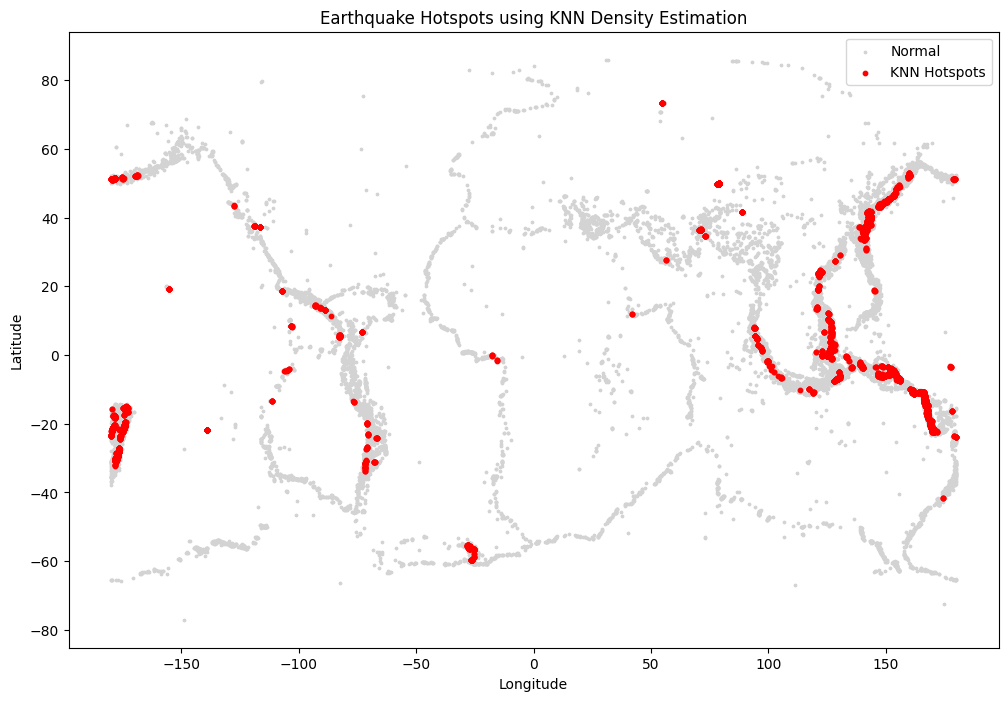

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# normal points
plt.scatter(
    df['Longitude'],
    df['Latitude'],
    s=3,
    c='lightgray',
    label='Normal'
)

# hotspots
hotspots = df[df['Hotspot'] == True]

plt.scatter(
    hotspots['Longitude'],
    hotspots['Latitude'],
    s=10,
    c='red',
    label='KNN Hotspots'
)

plt.title("Earthquake Hotspots using KNN Density Estimation")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()